# EDA Datasets Medical.csv
## Cargar el conjunto de Datos

In [ ]:
import pandas as pd
medical_df = pd.read_csv('medical.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


1. Averiguar información sobre este Datasets, ¿cual es su objetivo?
2. ¿Cuantas filas y columnas tiene?
3. ¿Cual predictores son numéricos y categóricos?
4. ¿Cuantos valores nulos tiene?
5. Averiguar la media, desviación standard, valor mínimo, máximo y Q1, Q2 y Q3. Respecto al tag de salida "cargos ¿Que puede observar entre su valor mínimo, máximo y su mediana Q2?

## 1 Sobre los Datos
edad: Edad del beneficiario principal.

sexo: Género del contratista del seguro: femenino, masculino.

IMC: Índice de masa corporal, que proporciona una comprensión de los pesos corporales que son relativamente altos o bajos en relación con la altura, índice objetivo del peso corporal (kg/m^2) utilizando la relación de altura a peso, idealmente de 18.5 a 24.9.

hijos: Número de hijos cubiertos por el seguro médico/Número de dependientes.

fumador: Si el contratista es fumador o no.

A pesar de que el número de características en este conjunto de datos es relativamente pequeño, aún nos cuenta mucho.
Una historia muy importante que obtenemos de este conjunto de datos es el efecto que tiene el tabaquismo en nuestras vidas, así como en nuestros bolsillos.

Como descubriremos, el tabaquismo resalta como el principal factor detrás de la variabilidad de los datos, especialmente en los cargos, que es un indicador del bienestar general de los individuos de la muestra.

De hecho, la diferencia entre fumadores y no fumadores es tan notable que predecir si alguien es fumador o no a partir de los datos mediante un modelo de ML se demuestra ser muy fácil y preciso, con una precisión del 99%.

Por lo tanto, junto con otros conocimientos interesantes que obtuvimos de esta tabla, espero que estos datos sean una advertencia para fumadores y no fumadores sobre la naturaleza peligrosa de esta sustancia.

In [ ]:
#2
medical_df.shape

(1338, 7)

Tiene 1338 filas y 7 columnas

In [ ]:
# 3
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Predictores numéricos: Las columnas 'age', 'bmi', 'children' y 'charges'

Predictores categóricos: Las columnas 'sex', 'smoker', 'region'

In [ ]:
# 4
medical_df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

El dataset no posee valores nulos

 5 - Averiguar la media, desviación standard, valor mínimo, máximo y Q1, Q2 y Q3. Respecto al tag de salida "cargos ¿Que puede observar entre su valor mínimo, máximo y su mediana Q2?

In [ ]:
medical_df.charges.describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

In [ ]:
medical_df.charges.median()

9382.033

El valor mínimo es: 1121.87

El valor máximo es: 63770.42

El valor de la mediana es: 9382.03

Podemos observar que la diferencia entre el valor mínimo y la mediana (Q2) es menor en comparación con la diferencia entre la mediana (Q2) y el valor máximo que posee una diferencia de 54388.39.

Esto sugiere una asimetría en la distribución de los datos, donde hay más datos concentrados en el lado derecho (valores altos) de la distribución.

Esto me indica la que hay valores atípicos (outliers) en el lado derecho de la distribución que están afectando el máximo

<Axes: xlabel='charges'>

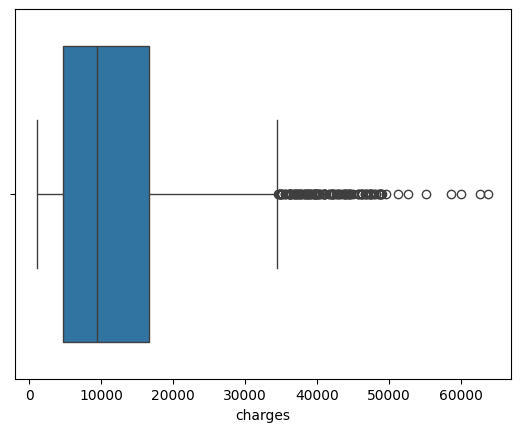

In [ ]:
sns.boxplot(x=medical_df['charges'])


## Análisis exploratorio y visualización
Exploremos los datos visualizando la distribución de valores en algunas columnas del conjunto de datos y las relaciones entre los "cargos" y otras columnas.

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Gráfico de Distribución de la "Edad"
* La edad es una columna numérica.
* La edad mínima en el conjunto de datos es 18 años y la edad máxima es 64.
* Hacer un gráfico de distribución de la edad (se podría utilizar bins).
* Hacer un diagrama de caja.

In [ ]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Edad minima:  18
Edad maxima:  64
Edad mediana:  39.0
Edad moda:  0    18
Name: age, dtype: int64


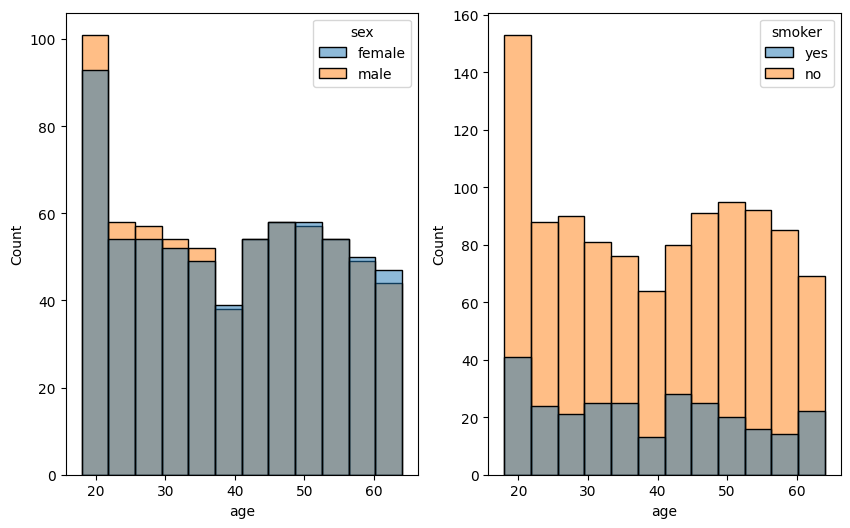

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
sns.histplot(x=medical_df['age'],hue = medical_df['sex'],ax = axes [0])
sns.histplot(x=medical_df['age'],hue = medical_df['smoker'],ax = axes [1])
print('Edad minima: ', min(medical_df['age']))
print('Edad maxima: ', max(medical_df['age']))
print('Edad mediana: ', medical_df['age'].median())
print('Edad moda: ', medical_df['age'].mode())
plt.show()

<Axes: xlabel='age', ylabel='Density'>

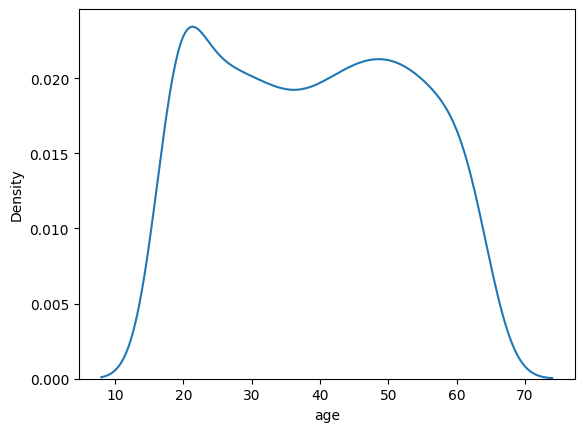

In [ ]:
sns.kdeplot(x=medical_df['age'])

<Axes: xlabel='age'>

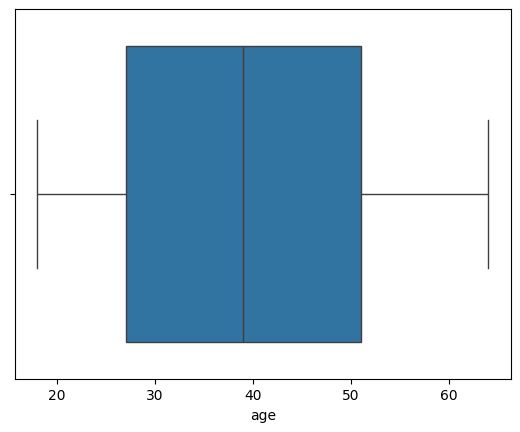

In [ ]:
sns.boxplot(x=medical_df['age'])

La distribución de edades en el conjunto de datos es casi uniforme, con entre 20 y 30 clientes en cada edad, excepto los de 18 y 19 años, que parecen tener más del doble de clientes que otras edades. La distribución uniforme podría deberse al hecho de que no hay una gran variación en el número de personas de una edad determinada (entre 18 y 64 años) en Estados Unidos.
### Gráfico de Distribución del "Índice de masa corporal"
Veamos la distribución del IMC (índice de masa corporal) de los clientes, utilizando un histograma y un diagrama de caja.

<Axes: xlabel='bmi', ylabel='Density'>

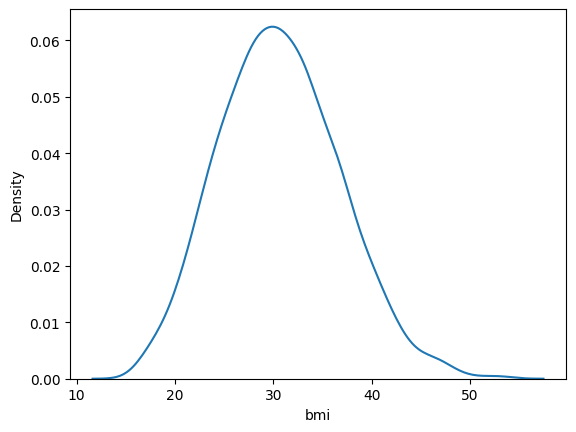

In [ ]:
sns.kdeplot(x=medical_df['bmi'])

Las mediciones del índice de masa corporal parecen formar una distribución gaussiana centrada alrededor del valor 30, con algunos valores atípicos hacia la derecha. Así es como se pueden interpretar los valores del IMC:

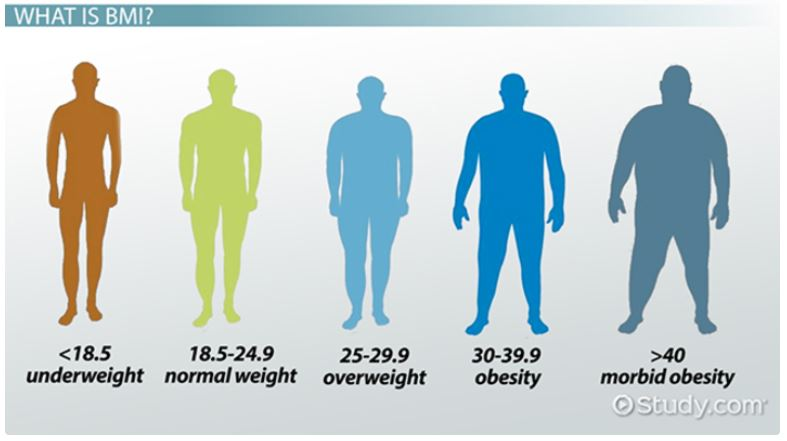

![IMC.JPG](attachment:IMC.JPG)

### Gráfico de Distribución de los "Cargos"
Visualicemos la distribución de "cargos", es decir, los cargos médicos anuales para los clientes. Esta es la columna que estamos tratando de predecir. Utilicemos también la columna categórica "fumador" para distinguir los cargos para fumadores y no fumadores.

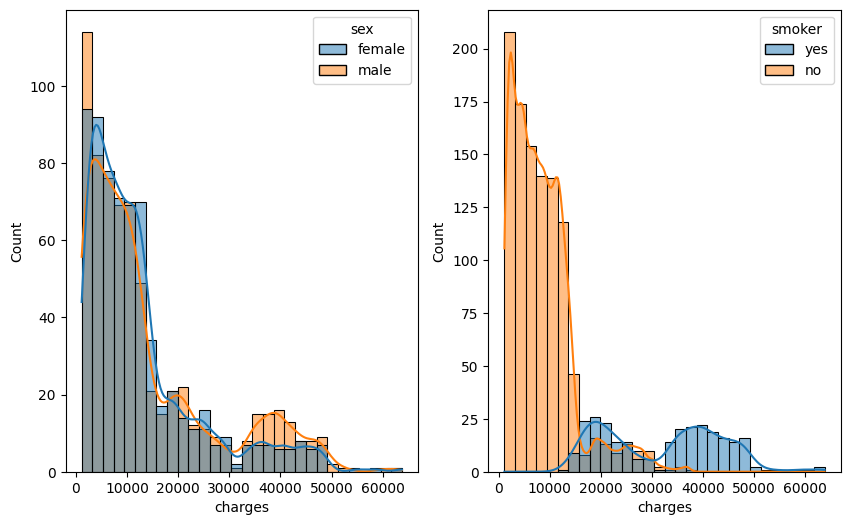

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
sns.histplot(x=medical_df['charges'],hue = medical_df['sex'],kde = True, kde_kws = {'bw_adjust': 0.5}, ax=axes[0])
sns.histplot(x=medical_df['charges'],hue = medical_df['smoker'],kde = True, kde_kws = {'bw_adjust': 0.5}, ax=axes[1])
plt.show()

Podemos hacer las siguientes observaciones del gráfico anterior:

* Para la mayoría de los clientes, los cargos médicos anuales son inferiores a $10.000. Sólo una pequeña fracción de los clientes tiene gastos médicos más elevados, posiblemente debido a accidentes, enfermedades graves y enfermedades genéticas. La distribución sigue una "ley de potencia".
* Existe una diferencia significativa en los gastos médicos entre fumadores y no fumadores. Mientras que la mediana para los no fumadores es 7300, la mediana para los fumadores está cerca de 35.000.
### Gráfico de Distribución de los "Fumador"
Visualicemos la distribución de la columna "fumador" (que contiene los valores "sí" y "no") usando un histograma.

In [ ]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

<Axes: xlabel='smoker', ylabel='count'>

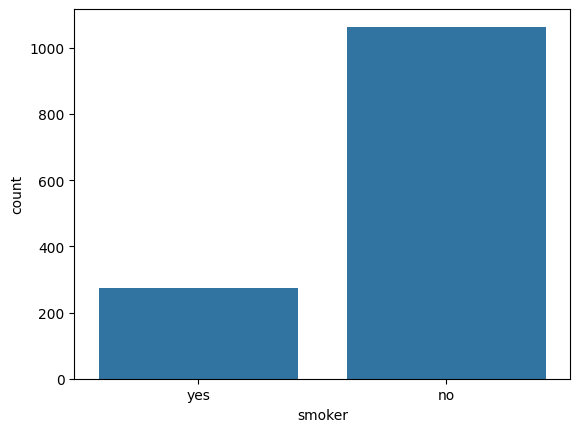

In [ ]:
sns.countplot(x=medical_df['smoker'])

<Axes: xlabel='smoker', ylabel='count'>

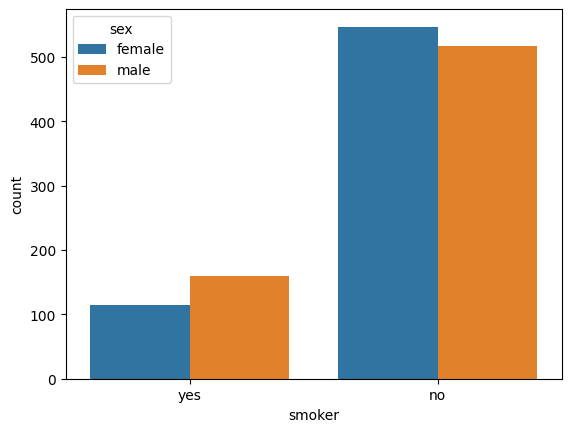

In [ ]:
sns.countplot(x=medical_df['smoker'],hue = medical_df['sex'])

Parece que el 20% de los clientes han informado que fuman. También podemos ver que fumar parece un hábito más común entre los hombres.

Habiendo examinado las columnas individuales, ahora podemos visualizar la relación entre los "cargos" (el valor que deseamos predecir) y otras columnas.

### Diagrama de Dispersión entre "Edad" y "cargos"
Visualicemos la relación entre "edad" y "cargos" usando un diagrama de dispersión. Cada punto del diagrama de dispersión representa un cliente. También usaremos valores en la columna "fumador" para colorear los puntos.

<Axes: xlabel='age', ylabel='charges'>

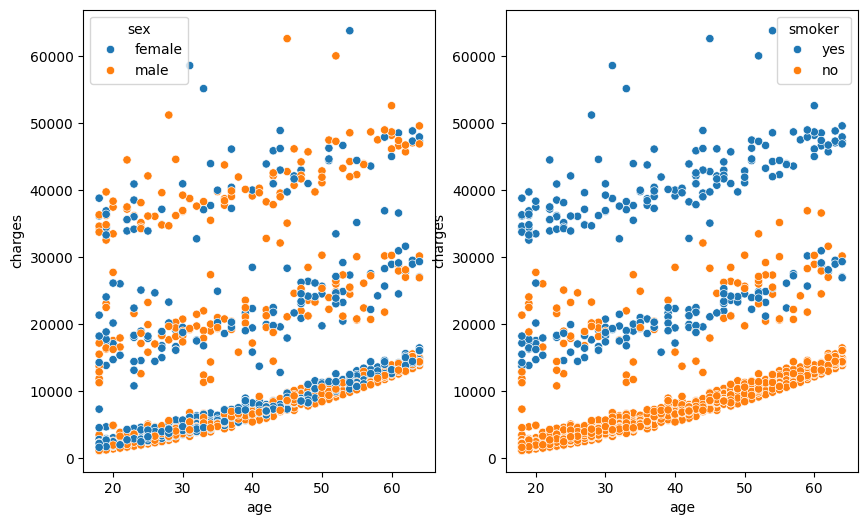

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
sns.scatterplot(x = 'age', y = 'charges', data = medical_df, hue = 'sex',ax = axes[0])
sns.scatterplot(x = 'age', y = 'charges', data = medical_df, hue = 'smoker',ax = axes[1])

Podemos hacer las siguientes observaciones del cuadro anterior:

* La tendencia general parece ser que los gastos médicos aumentan con la edad, como era de esperar. Sin embargo, existe una variación significativa en cada edad y está claro que la edad por sí sola no puede usarse para determinar con precisión los cargos médicos.

* Podemos ver tres "grupos" de puntos, cada uno de los cuales parece formar una línea con una pendiente creciente:

* El primer grupo, y el más grande, está formado principalmente por presumiblemente "no fumadores sanos" que tienen gastos médicos relativamente bajos en comparación con otros.

* El segundo grupo contiene una mezcla de fumadores y no fumadores. Es posible que en realidad se trate de dos grupos distintos pero superpuestos: "no fumadores con problemas médicos" y "fumadores sin problemas médicos importantes".

* El grupo final está formado exclusivamente por fumadores, presumiblemente fumadores con problemas médicos importantes que posiblemente estén relacionados o empeorados por el tabaquismo.
### Diagrama de Dispersión entre "IMC" y "cargos"
Visualicemos la relación entre el IMC (índice de masa corporal) y las cargas utilizando otro diagrama de dispersión. Una vez más, usaremos los valores de la columna "fumador" para colorear los puntos.

<Axes: xlabel='bmi', ylabel='charges'>

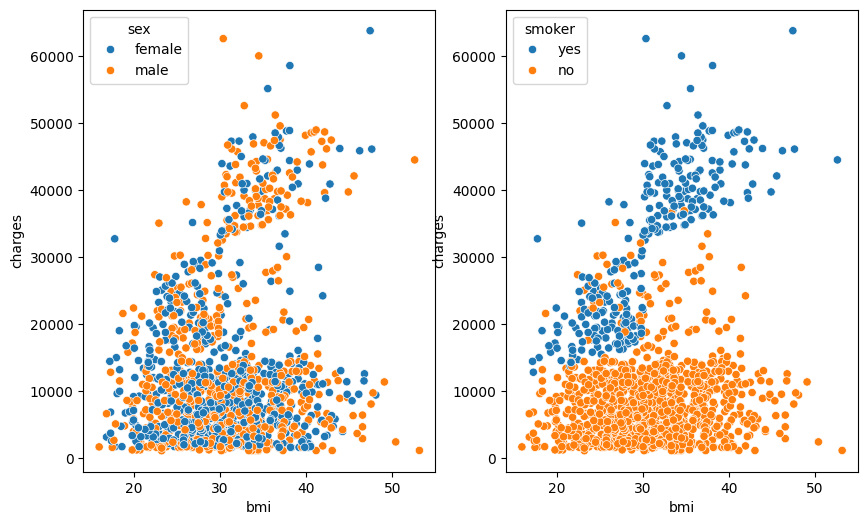

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
sns.scatterplot(x = 'bmi', y = 'charges', data = medical_df, hue = 'sex', ax = axes[0])
sns.scatterplot(x = 'bmi', y = 'charges', data = medical_df, hue = 'smoker', ax = axes[1])

Parece que para los no fumadores, un aumento en el IMC no parece estar relacionado con un aumento en los gastos médicos. Sin embargo, los gastos médicos parecen ser significativamente más altos para los fumadores con un IMC superior a 30.
### Matríz de Correlación

Así es como se pueden interpretar los coeficientes de correlación:

* **Fuerza**: Cuanto mayor sea el valor absoluto del coeficiente de correlación, más fuerte será la relación.

Los valores extremos de -1 y 1 indican una relación perfectamente lineal donde un cambio en una variable va acompañado de un cambio perfectamente consistente en la otra. Para estas relaciones, todos los puntos de datos caen en una línea. En la práctica, no verás ningún tipo de relación perfecta.

Un coeficiente de cero no representa una relación lineal. A medida que una variable aumenta, no hay tendencia en la otra variable a aumentar o disminuir.

Cuando el valor está entre 0 y +1/-1, existe una relación, pero no todos los puntos caen en una línea. A medida que r se acerca a -1 o 1, la fuerza de la relación aumenta y los puntos de datos tienden a acercarse a una línea.

* **Dirección**: El signo del coeficiente de correlación representa la dirección de la relación.

Los coeficientes positivos indican que cuando el valor de una variable aumenta, el valor de la otra variable también tiende a aumentar. Las relaciones positivas producen una pendiente ascendente en un diagrama de dispersión.

Los coeficientes negativos representan casos en los que el valor de una variable aumenta y el valor de la otra variable tiende a disminuir. Las relaciones negativas producen una pendiente descendente.

Aquí está la misma relación expresada visualmente:

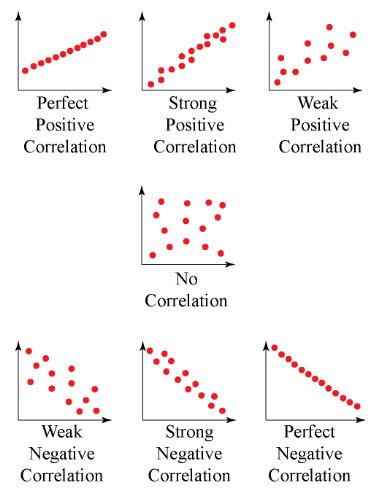

In [ ]:
medical_df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
# solo que quedo con los 4 predictores numéricos
eliminar = ['sex','smoker','region']
medical_df_num = medical_df.drop(eliminar, axis = 1)

medical_df_num

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


La librería Pandas también proporciona un método **.corr** para calcular los coeficientes de correlación entre todos los pares de columnas numéricas.

In [ ]:
medical_df_num.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


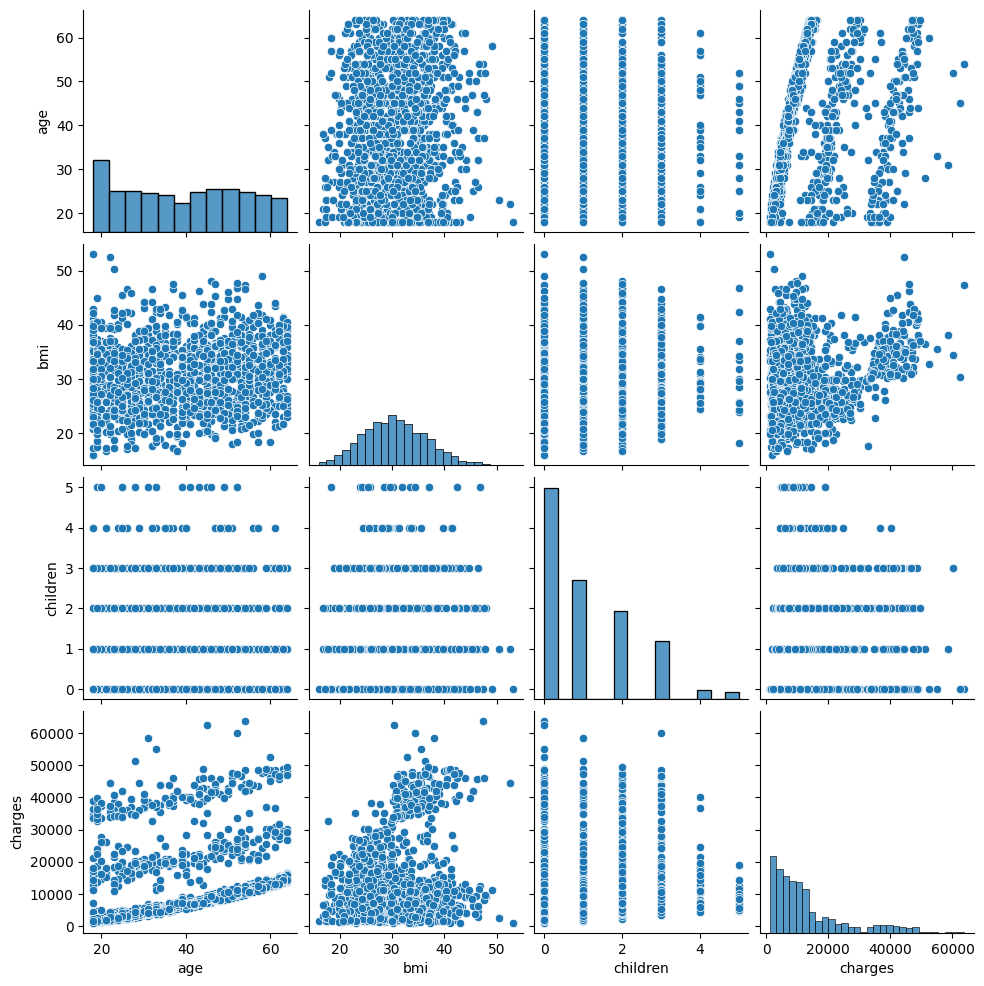

In [ ]:
sns.pairplot(medical_df_num)

Podemos ver todas las combinaciones de correlaciones con la librería Seaborn:

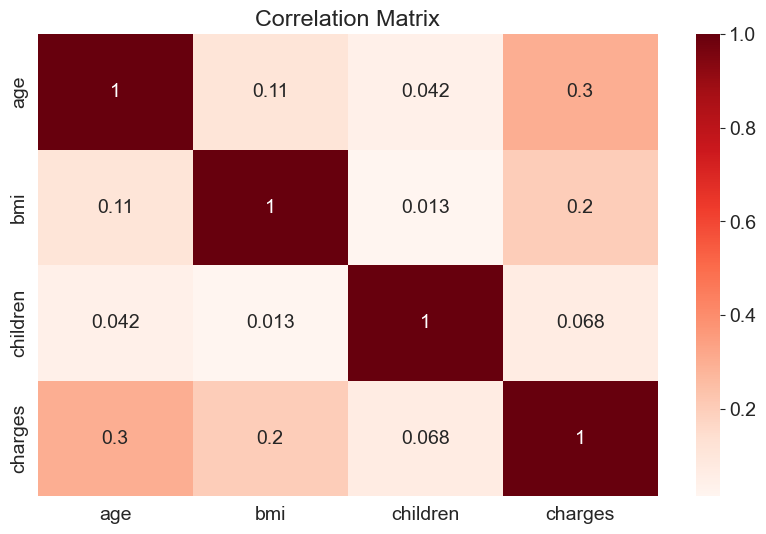

In [ ]:
sns.heatmap(medical_df_num.corr(), cmap='Reds', annot=True)
plt.title('Correlation Matrix');